# Feature sifting on multi-GEOFF

**Problem.** Stationary 2-task multi-GEOFF: two independent GEOFF teachers, 10 inputs and
1 output each (20 inputs, 2 outputs in total), 4 hidden LTUs split between them, and
$N(0, 1)$ observation noise. Per-output MSE is 1.0 for an optimal predictor and 2.0 for
the mean predictor. `multi_geoff_sifting.py` wraps it into the **feature sifting** setting
of `phd/jax_core/tasks/feature_sifting.py`: each step the learner may cut connections, and
every cut connection is immediately replaced by a new one. The difference from the
original sifting task is that the candidate pool is *fixed* — it is the problem's own 20
inputs — so sifting means finding which real features each output should read, not waiting
for a lucky procedural draw. The teacher is block-diagonal, so the 10 cross-task features
of an output are pure noise for it and the 10 within-task ones are what it needs.

**Learner.** A linear predictor per output, plus a bias. It starts with 20 connections, 10
per output, drawn without replacement from the pool, and every weight starts at zero. A
connection is one (output, feature) pair, so an output is never wired to the same feature
twice; the grid of all such pairs is the padded weight matrix, of which only the connected
positions are live (their input is zeroed otherwise). A replacement picks a **random
output** and then a **random feature that output is free of**, so the total stays at 20
while the split between the two outputs drifts over a run.

**Runs.** LMS at a fixed step-size, Autostep, and Autostep + generate & test, which cuts a
connection the step its weight crosses zero. Only the last one rewires; the other two show
what the initial random wiring is worth.

In [17]:
import os
import sys

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import seaborn as sns

from phd.jax_core.optimizers.idbd import optax_idbd, IDBDState
from phd.jax_core.tasks.multi_geoff import MultiGEOFFTask
from phd.jax_core.utils import stack_pytrees, tree_replace
from phd.research_utils.analysis.analysis_utils import get_color_palette

NOTEBOOK_DIR = os.path.abspath('.')
if NOTEBOOK_DIR not in sys.path:      # make the sibling modules importable
    sys.path.insert(0, NOTEBOOK_DIR)

from multi_geoff_sifting import MultiGEOFFSifting

sns.set_theme('notebook', 'white')
%matplotlib inline

In [18]:
# --- Problem ---
N_TASKS = 2
N_FEATURES_PER_TASK = 10
N_HIDDEN_PER_TASK = 10                # 4 hidden LTUs in total
N_OUTPUTS_PER_TASK = 1
NOISE_STD = 1.0
INPUT_BOUNDS = (-1.0, 1.0)           # uniform input range, shared by every problem instance

# --- Learner ---
N_CONNECTIONS_PER_OUTPUT = 10        # the initial split; the total is conserved, the split is not

# --- Optimizers ---
LMS_LR = 0.001
INIT_LR = 1e-6                       # Autostep's starting step-size for every connection
META_LR = 0.02

# --- Training and recording ---
NUM_STEPS = 2_000_000
N_SEEDS = 30                         # vmapped into one scan; scan width is nearly free
N_SNAPSHOTS = 200                    # recording points per run
BASE_SEED = 0

# --- Derived ---
N_FEATURES = N_TASKS * N_FEATURES_PER_TASK
N_OUTPUTS = N_TASKS * N_OUTPUTS_PER_TASK
N_SLOTS = N_FEATURES + 1                 # one slot per (output, feature) pair, plus a bias column
N_CONNECTIONS = N_OUTPUTS * N_CONNECTIONS_PER_OUTPUT
IRREDUCIBLE_MSE = NOISE_STD ** 2         # per-output MSE of an optimal predictor
BASELINE_MSE = IRREDUCIBLE_MSE + 1.0     # the mean predictor sits 1 above it
BLOCK_LEN = NUM_STEPS // N_SNAPSHOTS

## Learners

Each method is a self-contained `eqx.Module` with `init()` and `step(inputs, y, active)`, and
carries the `prune_mask` the task reads to rewire. `inputs` and `active` are the
`(n_outputs, n_features)` connection grid, padded here with the bias column; the weight matrix
covers the whole grid and unconnected positions are held inert.

In [19]:
def slot_inputs(inputs, active):
    """Pad the connection grid with the bias column: a constant-1 input, always connected.

    Keeping the bias inside the weight matrix is what Autostep's per-output-row normalizer
    needs — it does not support a separate bias vector.
    """
    ones = jnp.ones((N_OUTPUTS, 1))
    return (jnp.concatenate([inputs, ones], axis=1),
            jnp.concatenate([active, ones.astype(bool)], axis=1))


def linear_loss_and_grads(w, x, y):
    """Squared error summed over outputs, and the LMS gradient `delta * x`.

    That is the exact gradient up to the constant factor 2, which is folded into the step-size.
    An unconnected slot has `x = 0`, so it contributes nothing to either.
    """
    error = jnp.sum(w * x, axis=-1) - y
    return jnp.sum(error ** 2), error[:, None] * x


def hold_inactive(w, opt_state, active):
    """Hold every unconnected slot at its starting state: zero weight, `INIT_LR`, no traces.

    An unconnected slot's input is zeroed, so its gradient and traces are already frozen — the
    one thing that still moves it is Autostep's per-output normalizer, which divides the whole
    row. Resetting the unconnected slots every step is the simplest way to make a connection
    formed later start with no inherited history, whichever slot it lands in.
    """
    return jnp.where(active, w, 0.0), IDBDState(
        init_beta=opt_state.init_beta,
        beta=jnp.where(active, opt_state.beta, opt_state.init_beta),
        h=jnp.where(active, opt_state.h, 0.0),
        v=jnp.where(active, opt_state.v, 0.0),
    )

In [20]:
class LMS(eqx.Module):
    """Least mean squares at a fixed step-size on the initial wiring; never rewires."""
    w: jax.Array
    prune_mask: jax.Array

    @classmethod
    def init(cls):
        return cls(w=jnp.zeros((N_OUTPUTS, N_SLOTS)),
                   prune_mask=jnp.zeros((N_OUTPUTS, N_FEATURES), dtype=bool))

    def step(self, inputs, y, active):
        x, _ = slot_inputs(inputs, active)
        loss, grads = linear_loss_and_grads(self.w, x, y)
        return tree_replace(self, w=self.w - LMS_LR * grads), loss   # prune_mask stays all-False

In [21]:
class Autostep(eqx.Module):
    """Autostep (IDBD) on the initial wiring: a step-size per connection, but no rewiring."""
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    w: jax.Array
    opt_state: optax.OptState
    prune_mask: jax.Array

    @classmethod
    def init(cls):
        optimizer = optax_idbd(init_lr=INIT_LR, meta_lr=META_LR, autostep=True)
        w = jnp.zeros((N_OUTPUTS, N_SLOTS))
        return cls(optimizer=optimizer, w=w, opt_state=optimizer.init(w),
                   prune_mask=jnp.zeros((N_OUTPUTS, N_FEATURES), dtype=bool))

    def step(self, inputs, y, active):
        x, active = slot_inputs(inputs, active)
        loss, grads = linear_loss_and_grads(self.w, x, y)
        # Autostep consumes the loss gradient and the prediction gradient (= x, this being a
        # linear model), and normalizes each output's row of step-sizes on its own — which is
        # what a loss that is a plain sum of per-output squared errors calls for.
        updates, opt_state = self.optimizer.update((grads, x), self.opt_state, self.w)
        w, opt_state = hold_inactive(self.w + updates, opt_state, active)
        return tree_replace(self, w=w, opt_state=opt_state), loss

In [22]:
class AutostepGT(eqx.Module):
    """Autostep + generate & test: a connection is cut the step its weight crosses zero.

    The task replaces every cut connection with one between a random output and a random
    feature that output is free of, so the learner keeps the same number of weights and
    trades away the ones a real gradient is no longer holding off zero. A new connection
    arrives at exactly `w = 0` (`hold_inactive` parks every unconnected slot there), so the
    product below is zero and it is never cut on its first step.
    """
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    w: jax.Array
    opt_state: optax.OptState
    prune_mask: jax.Array

    @classmethod
    def init(cls):
        optimizer = optax_idbd(init_lr=INIT_LR, meta_lr=META_LR, autostep=True)
        w = jnp.zeros((N_OUTPUTS, N_SLOTS))
        return cls(optimizer=optimizer, w=w, opt_state=optimizer.init(w),
                   prune_mask=jnp.zeros((N_OUTPUTS, N_FEATURES), dtype=bool))

    def step(self, inputs, y, active):
        x, active = slot_inputs(inputs, active)
        loss, grads = linear_loss_and_grads(self.w, x, y)
        updates, opt_state = self.optimizer.update((grads, x), self.opt_state, self.w)
        w, opt_state = hold_inactive(self.w + updates, opt_state, active)

        # The bias column is not a connection, so it is sliced back off the mask.
        prune_mask = ((self.w * w < 0.0) & active)[:, :N_FEATURES]
        return tree_replace(self, w=w, opt_state=opt_state, prune_mask=prune_mask), loss

## Training

In [23]:
def make_task(seed):
    task = MultiGEOFFTask(
        N_TASKS, n_features_per_task=N_FEATURES_PER_TASK, n_hidden_per_task=N_HIDDEN_PER_TASK,
        n_outputs_per_task=N_OUTPUTS_PER_TASK, noise_std=NOISE_STD, input_bounds=INPUT_BOUNDS,
        seed=seed)
    return MultiGEOFFSifting(task, N_CONNECTIONS_PER_OUTPUT, key=jax.random.PRNGKey(seed))


def train(learner, task):
    """`NUM_STEPS` of online training, summarized into `N_SNAPSHOTS` equal blocks."""
    def one_step(carry, _):
        learner, task = carry
        task, (inputs, y) = task.step(learner.prune_mask)     # the task rewires what was cut
        learner, loss = learner.step(inputs, y, task.active)
        return (learner, task), (loss, jnp.sum(learner.prune_mask))

    def block(carry, _):
        carry, (losses, n_cut) = jax.lax.scan(one_step, carry, length=BLOCK_LEN)
        task = carry[1]
        return carry, (losses.mean() / N_OUTPUTS, n_cut.mean(),
                       jnp.sum(task.active & task.useful) / N_CONNECTIONS,
                       jnp.sum(task.active, axis=-1))

    _, out = jax.lax.scan(block, (learner, task), length=N_SNAPSHOTS)
    return out


def run(make_learner):
    """Train `N_SEEDS` independent runs — a fresh teacher and wiring each — in one vmapped scan."""
    tasks = stack_pytrees([make_task(BASE_SEED + s) for s in range(N_SEEDS)])
    keys = ('mse', 'cut_rate', 'useful', 'per_output')
    out = jax.jit(jax.vmap(lambda task: train(make_learner(), task)))(tasks)
    return {'steps': np.arange(1, N_SNAPSHOTS + 1) * BLOCK_LEN,
            **{k: np.asarray(v) for k, v in zip(keys, out)}}


runs = {
    f'LMS (lr {LMS_LR:g})': run(LMS.init),
    'Autostep': run(Autostep.init),
    'Autostep + G&T': run(AutostepGT.init),
}

## Results

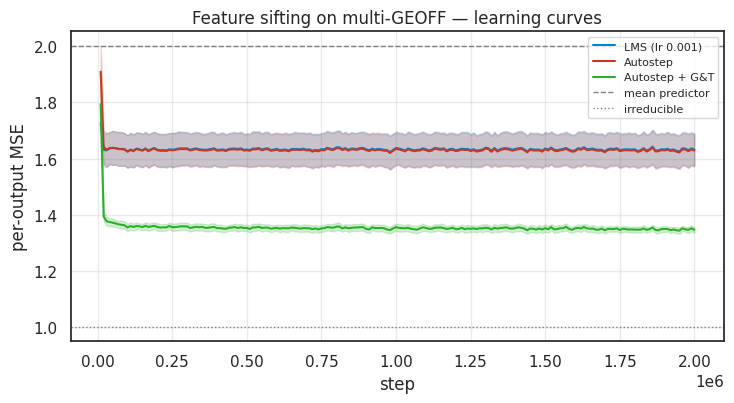

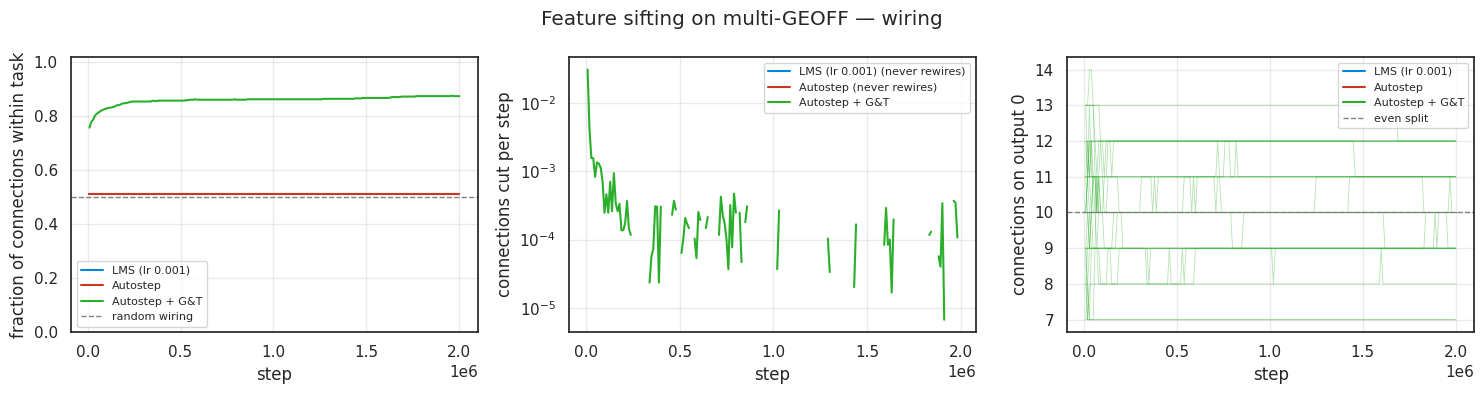

In [24]:
def plot_curves(runs):
    """Per-output MSE per method, mean +- 2 standard errors over seeds."""
    plt.figure(figsize=(7.5, 4.2))
    for (label, res), color in zip(runs.items(), get_color_palette(n=len(runs))):
        mean = res['mse'].mean(0)
        sem = res['mse'].std(0) / np.sqrt(N_SEEDS)
        plt.plot(res['steps'], mean, color=color, label=label)
        plt.fill_between(res['steps'], mean - 2 * sem, mean + 2 * sem, color=color, alpha=0.2)
    plt.axhline(BASELINE_MSE, ls='--', c='gray', lw=1, label='mean predictor')
    plt.axhline(IRREDUCIBLE_MSE, ls=':', c='gray', lw=1, label='irreducible')
    plt.xlabel('step')
    plt.ylabel('per-output MSE')
    plt.title('Feature sifting on multi-GEOFF — learning curves')
    plt.grid(alpha=0.4)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_wiring(runs):
    """What the rewiring does: how much of it is within-task, how fast it churns, and how the
    connections split between the two outputs (thin lines: individual seeds)."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for (label, res), color in zip(runs.items(), get_color_palette(n=len(runs))):
        axes[0].plot(res['steps'], res['useful'].mean(0), color=color, label=label)

        rate = res['cut_rate'].mean(0)
        if np.any(rate > 0):
            axes[1].plot(res['steps'], np.where(rate > 0, rate, np.nan), color=color, label=label)
        else:
            axes[1].plot([], [], color=color, label=f'{label} (never rewires)')

        axes[2].plot(res['steps'], res['per_output'][..., 0].T, color=color, lw=0.6, alpha=0.35)
        axes[2].plot([], [], color=color, label=label)          # legend proxy

    axes[0].axhline(0.5, ls='--', c='gray', lw=1, label='random wiring')
    axes[0].set_ylabel('fraction of connections within task')
    axes[0].set_ylim(0, 1.02)
    axes[1].set_ylabel('connections cut per step')
    axes[1].set_yscale('log')
    axes[2].axhline(N_CONNECTIONS_PER_OUTPUT, ls='--', c='gray', lw=1, label='even split')
    axes[2].set_ylabel('connections on output 0')
    for ax in axes:
        ax.set_xlabel('step')
        ax.grid(alpha=0.4)
        ax.legend(fontsize=8)
    fig.suptitle('Feature sifting on multi-GEOFF — wiring')
    fig.tight_layout()
    plt.show()


plot_curves(runs)
plot_wiring(runs)